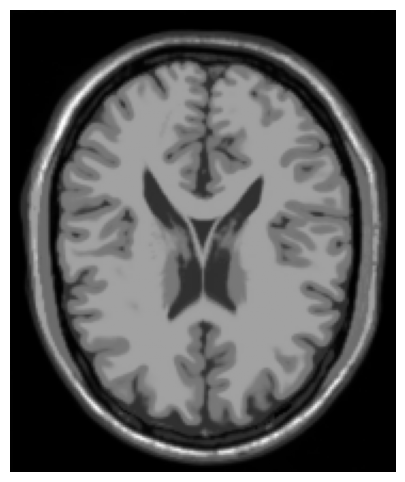

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MRI_PATH = "t1_icbm_normal_1mm_pn0_rf0.rawb"

DEPTH = 181
HEIGHT = 217
WIDTH = 181

mri_volume = np.fromfile(MRI_PATH, dtype=np.uint8)

expected_voxels = DEPTH * HEIGHT * WIDTH

if mri_volume.size != expected_voxels:
    raise ValueError(
        f"Expected {expected_voxels} voxels "
        f"but found {mri_volume.size}"
    )

mri_volume = mri_volume.reshape(DEPTH, HEIGHT, WIDTH)

mri_volume = mri_volume.astype(np.float32) / 255.0

slice_index = DEPTH // 2

plt.figure(figsize=(6, 6))

plt.imshow(
    mri_volume[slice_index],
    cmap="gray"
)

plt.axis("off")

plt.show()

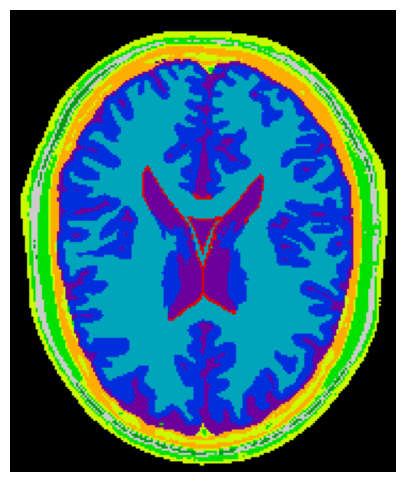

In [2]:
import numpy as np
import matplotlib.pyplot as plt

GT_PATH = "phantom_1.0mm_normal_crisp.rawb"

DEPTH = 181
HEIGHT = 217
WIDTH = 181

gt_volume = np.fromfile(GT_PATH, dtype=np.uint8)

expected_voxels = DEPTH * HEIGHT * WIDTH

if gt_volume.size != expected_voxels:
    raise ValueError(
        f"Expected {expected_voxels} voxels "
        f"but found {gt_volume.size}"
    )

gt_volume = gt_volume.reshape(DEPTH, HEIGHT, WIDTH)

unique_labels = np.unique(gt_volume)

slice_index = DEPTH // 2

plt.figure(figsize=(6, 6))

plt.imshow(
    gt_volume[slice_index],
    cmap="nipy_spectral"
)

plt.axis("off")

plt.show()

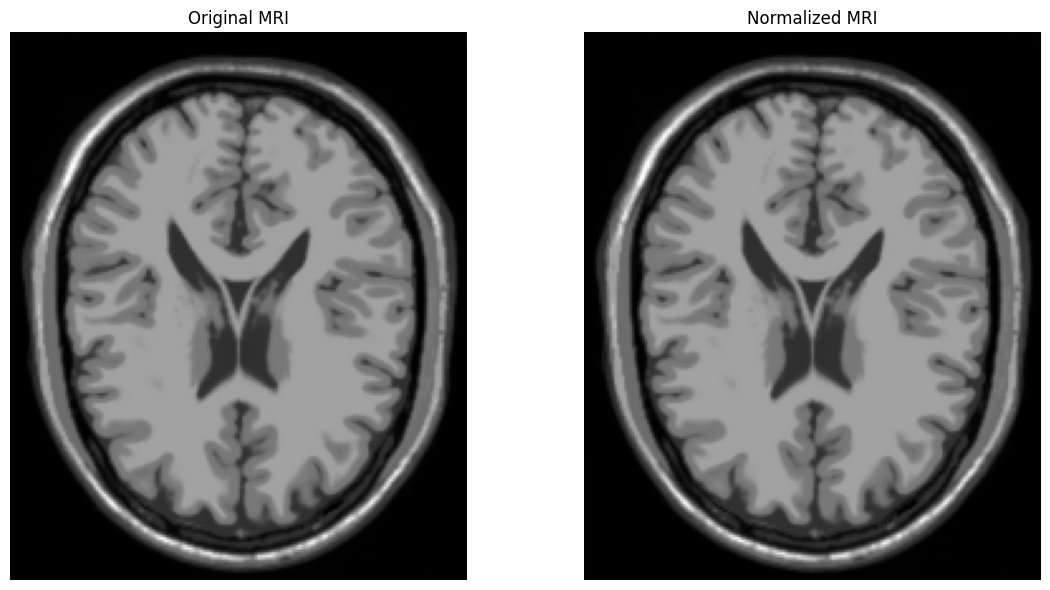

In [3]:
import numpy as np
import matplotlib.pyplot as plt

MRI_PATH = "t1_icbm_normal_1mm_pn0_rf0.rawb"

DEPTH = 181
HEIGHT = 217
WIDTH = 181

# ============================================================
# LOAD MRI
# ============================================================

volume = np.fromfile(
    MRI_PATH,
    dtype=np.uint8
)

expected_voxels = DEPTH * HEIGHT * WIDTH

if volume.size != expected_voxels:

    raise ValueError(
        f"Expected {expected_voxels} voxels "
        f"but found {volume.size}"
    )

volume = volume.reshape(
    DEPTH,
    HEIGHT,
    WIDTH
).astype(np.float32)

# ============================================================
# NORMALIZE ONLY
# ============================================================

normalized_mri = volume / 255.0

# ============================================================
# DISPLAY
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(12, 6))

# ------------------------------------------------------------
# ORIGINAL MRI
# ------------------------------------------------------------

plt.subplot(1, 2, 1)

plt.imshow(
    volume[slice_index],
    cmap="gray"
)

plt.title("Original MRI")

plt.axis("off")

# ------------------------------------------------------------
# NORMALIZED MRI
# ------------------------------------------------------------

plt.subplot(1, 2, 2)

plt.imshow(
    normalized_mri[slice_index],
    cmap="gray"
)

plt.title("Normalized MRI")

plt.axis("off")

plt.tight_layout()

plt.show()

Image Patches Shape = (113, 32, 32, 32, 1)
Mask Patches Shape = (113, 32, 32, 32)


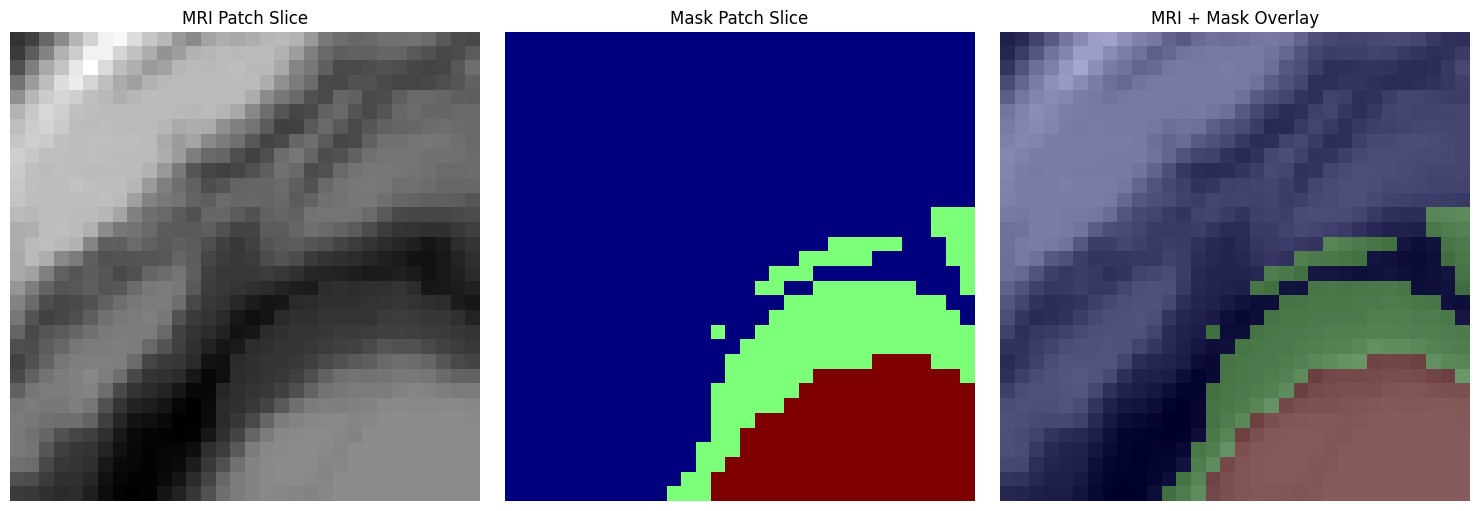

In [17]:
import numpy as np
import matplotlib.pyplot as plt

PATCH_SIZE = 32
STRIDE = 32

gt_volume[gt_volume > 3] = 0

image_patches = []

mask_patches = []

DEPTH, HEIGHT, WIDTH = volume.shape

# ============================================================
# PATCH EXTRACTION
# ============================================================

for z in range(
    0,
    DEPTH - PATCH_SIZE + 1,
    STRIDE
):

    for y in range(
        0,
        HEIGHT - PATCH_SIZE + 1,
        STRIDE
    ):

        for x in range(
            0,
            WIDTH - PATCH_SIZE + 1,
            STRIDE
        ):

            image_patch = volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            mask_patch = gt_volume[
                z:z+PATCH_SIZE,
                y:y+PATCH_SIZE,
                x:x+PATCH_SIZE
            ]

            # ------------------------------------------------
            # KEEP ONLY VALID BRAIN PATCHES
            # ------------------------------------------------

            if (
                np.sum(image_patch) > 5
                and
                np.sum(mask_patch > 0) > 100
            ):

                image_patches.append(
                    image_patch
                )

                mask_patches.append(
                    mask_patch
                )

# ============================================================
# CONVERT TO NUMPY
# ============================================================

image_patches = np.array(
    image_patches,
    dtype=np.float32
)

mask_patches = np.array(
    mask_patches,
    dtype=np.uint8
)

# ============================================================
# ADD CHANNEL DIMENSION
# ============================================================

image_patches = np.expand_dims(
    image_patches,
    axis=-1
)

print("Image Patches Shape =",
      image_patches.shape)

print("Mask Patches Shape =",
      mask_patches.shape)

# ============================================================
# SELECT PATCH WITH MOST LABELS
# ============================================================
best_patch_index = 0

max_unique_labels = 0

for i in range(len(mask_patches)):

    unique_labels = np.unique(
        mask_patches[i]
    )

    unique_count = len(unique_labels)

    if unique_count > max_unique_labels:

        max_unique_labels = unique_count

        best_patch_index = i

# ============================================================
# VISUALIZATION
# ============================================================

sample_patch = image_patches[
    best_patch_index
]

sample_mask = mask_patches[
    best_patch_index
]

middle_slice = PATCH_SIZE // 2

plt.figure(figsize=(15, 5))

# ------------------------------------------------------------
# MRI PATCH
# ------------------------------------------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    sample_patch[middle_slice, :, :, 0],
    cmap="gray"
)

plt.title("MRI Patch Slice")

plt.axis("off")

# ------------------------------------------------------------
# MASK PATCH
# ------------------------------------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    sample_mask[middle_slice],
    cmap="jet"
)

plt.title("Mask Patch Slice")

plt.axis("off")

# ------------------------------------------------------------
# OVERLAY
# ------------------------------------------------------------

plt.subplot(1, 3, 3)

plt.imshow(
    sample_patch[middle_slice, :, :, 0],
    cmap="gray"
)

plt.imshow(
    sample_mask[middle_slice],
    cmap="jet",
    alpha=0.35
)

plt.title("MRI + Mask Overlay")

plt.axis("off")

plt.tight_layout()

plt.show()

In [18]:
import torch
import numpy as np

if isinstance(image_patches, np.ndarray):

    image_patches = torch.from_numpy(
        image_patches
    ).float()

if isinstance(mask_patches, np.ndarray):

    mask_patches = torch.from_numpy(
        mask_patches
    ).long()

if len(image_patches.shape) == 5:

    image_patches = image_patches.permute(
        0, 4, 1, 2, 3
    )

print("Image Tensor Shape =",
      image_patches.shape)

print("Mask Tensor Shape =",
      mask_patches.shape)

print("\nUnique Labels =",
      torch.unique(mask_patches))

Image Tensor Shape = torch.Size([113, 1, 32, 32, 32])
Mask Tensor Shape = torch.Size([113, 32, 32, 32])

Unique Labels = tensor([0, 1, 2, 3])


In [19]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super(UNet3D, self).__init__()

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(
            kernel_size=2
        )

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(
            kernel_size=2
        )

        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        p1 = self.pool1(e1)

        e2 = self.enc2(p1)

        p2 = self.pool2(e2)

        e3 = self.enc3(p2)

        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)

        u3 = torch.cat(
            [u3, e3],
            dim=1
        )

        d3 = self.dec3(u3)

        u2 = self.up2(d3)

        u2 = torch.cat(
            [u2, e2],
            dim=1
        )

        d2 = self.dec2(u2)

        u1 = self.up1(d2)

        u1 = torch.cat(
            [u1, e1],
            dim=1
        )

        d1 = self.dec1(u1)

        out = self.final(d1)

        return out

model = UNet3D(
    in_channels=1,
    out_channels=4
)

sample_input = torch.randn(
    2,
    1,
    32,
    32,
    32
)

output = model(sample_input)

print("Output Shape =", output.shape)

Output Shape = torch.Size([2, 4, 32, 32, 32])


In [20]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super(UNet3D, self).__init__()

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        u3 = torch.cat([u3, e3], dim=1)
        d3 = self.dec3(u3)

        u2 = self.up2(d3)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.final(d1)

        return out

model = UNet3D(
    in_channels=1,
    out_channels=4
)

sample_input = torch.randn(
    2,
    1,
    32,
    32,
    32
)

output = model(sample_input)

print("Output Shape =", output.shape)

print("\nClasses : [0 = Background, 1 = CSF, 2 = Gray Matter, 3 = White Matter]")


Output Shape = torch.Size([2, 4, 32, 32, 32])

Classes : [0 = Background, 1 = CSF, 2 = Gray Matter, 3 = White Matter]


In [21]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super(UNet3D, self).__init__()

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        u3 = torch.cat([u3, e3], dim=1)
        d3 = self.dec3(u3)

        u2 = self.up2(d3)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.final(d1)

        return out

model = UNet3D(
    in_channels=1,
    out_channels=4
)

sample_input = torch.randn(
    2,
    1,
    32,
    32,
    32
)

output = model(sample_input)

print("Output Shape =", output.shape)

print("\nClasses")
print("0 = Background")
print("1 = CSF")
print("2 = Gray Matter")
print("3 = White Matter")

Output Shape = torch.Size([2, 4, 32, 32, 32])

Classes
0 = Background
1 = CSF
2 = Gray Matter
3 = White Matter


In [22]:
import torch
import torch.nn as nn

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH = 32
HEIGHT = 32
WIDTH = 32

decoder_output = torch.randn(
    BATCH_SIZE,
    32,
    DEPTH,
    HEIGHT,
    WIDTH
)

final_layer = nn.Conv3d(
    in_channels=32,
    out_channels=NUM_CLASSES,
    kernel_size=1
)

output = final_layer(
    decoder_output
)

print("Output Shape =", output.shape)

voxel_prediction = output[
    0,
    :,
    16,
    16,
    16
]

print("\nRaw Scores")
print(voxel_prediction)

probabilities = torch.softmax(
    output,
    dim=1
)

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print("\nVoxel Probabilities")
print(voxel_probabilities)

predicted_class = torch.argmax(
    voxel_probabilities
)

class_names = {
    0: "Background",
    1: "CSF",
    2: "Gray Matter",
    3: "White Matter"
}

print("\nPredicted Class =", predicted_class.item())

print("Predicted Tissue =",
      class_names[predicted_class.item()])

Output Shape = torch.Size([2, 4, 32, 32, 32])

Raw Scores
tensor([ 0.3342, -0.5344, -0.8601, -0.6975], grad_fn=<SelectBackward0>)

Voxel Probabilities
tensor([0.4810, 0.2018, 0.1457, 0.1714], grad_fn=<SelectBackward0>)

Predicted Class = 0
Predicted Tissue = Background


In [23]:
import torch
import torch.nn as nn

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH = 32
HEIGHT = 32
WIDTH = 32

output = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH
)

print("Output Shape =", output.shape)

voxel_scores = output[
    0,
    :,
    16,
    16,
    16
]

print("\nRaw Scores")
print(voxel_scores)

probabilities = torch.softmax(
    output,
    dim=1
)

voxel_probabilities = probabilities[
    0,
    :,
    16,
    16,
    16
]

print("\nVoxel Probabilities")
print(voxel_probabilities)

print("\nProbability Sum =",
      torch.sum(voxel_probabilities))

predicted_class = torch.argmax(
    voxel_probabilities
)

class_names = {
    0: "Background",
    1: "CSF",
    2: "Gray Matter",
    3: "White Matter"
}

print("\nPredicted Class =",
      predicted_class.item())

print("Predicted Tissue =",
      class_names[predicted_class.item()])

Output Shape = torch.Size([2, 4, 32, 32, 32])

Raw Scores
tensor([-0.0056,  0.8391,  0.6159, -0.8747])

Voxel Probabilities
tensor([0.1783, 0.4150, 0.3320, 0.0748])

Probability Sum = tensor(1.0000)

Predicted Class = 1
Predicted Tissue = CSF


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

BATCH_SIZE = 2

NUM_CLASSES = 4

DEPTH = 32
HEIGHT = 32
WIDTH = 32

predictions = torch.randn(
    BATCH_SIZE,
    NUM_CLASSES,
    DEPTH,
    HEIGHT,
    WIDTH,
    requires_grad=True
)

ground_truth = torch.randint(
    0,
    NUM_CLASSES,
    (
        BATCH_SIZE,
        DEPTH,
        HEIGHT,
        WIDTH
    )
)

class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-5
    ):

        super(DiceLoss, self).__init__()

        self.smooth = smooth

    def forward(
        self,
        predictions,
        targets
    ):

        targets_one_hot = F.one_hot(
            targets,
            NUM_CLASSES
        )

        targets_one_hot = targets_one_hot.permute(
            0,
            4,
            1,
            2,
            3
        ).float()

        predictions = predictions.contiguous().view(
            predictions.shape[0],
            predictions.shape[1],
            -1
        )

        targets_one_hot = targets_one_hot.contiguous().view(
            targets_one_hot.shape[0],
            targets_one_hot.shape[1],
            -1
        )

        intersection = (
            predictions *
            targets_one_hot
        ).sum(dim=2)

        union = (
            predictions.sum(dim=2)
            +
            targets_one_hot.sum(dim=2)
        )

        dice_score = (
            2.0 * intersection + self.smooth
        ) / (
            union + self.smooth
        )

        dice_loss = 1 - dice_score.mean()

        return dice_loss

probabilities = F.softmax(
    predictions,
    dim=1
)

dice_loss_function = DiceLoss()

dice_loss = dice_loss_function(
    probabilities,
    ground_truth
)

cross_entropy_loss_function = nn.CrossEntropyLoss()

cross_entropy_loss = cross_entropy_loss_function(
    predictions,
    ground_truth
)

combined_loss = (
    dice_loss +
    cross_entropy_loss
)

print("Dice Loss =",
      dice_loss.item())

print("CrossEntropy Loss =",
      cross_entropy_loss.item())

print("Combined Loss =",
      combined_loss.item())

Dice Loss = 0.750167965888977
CrossEntropy Loss = 1.719893217086792
Combined Loss = 2.4700613021850586


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = UNet3D(
    in_channels=1,
    out_channels=4
).to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

images = torch.randn(
    2,
    1,
    32,
    32,
    32
).to(DEVICE)

masks = torch.randint(
    0,
    4,
    (
        2,
        32,
        32,
        32
    )
).to(DEVICE)

outputs = model(images)

criterion = nn.CrossEntropyLoss()

loss = criterion(
    outputs,
    masks
)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("Device =", DEVICE)

print("Output Shape =",
      outputs.shape)

print("Loss =",
      loss.item())

Device = cpu
Output Shape = torch.Size([2, 4, 32, 32, 32])
Loss = 1.3880853652954102


In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =", DEVICE)

NUM_CLASSES = 4

# ============================================================
# DATASET
# ============================================================

dataset = TensorDataset(
    image_patches,
    mask_patches
)

BATCH_SIZE = 2

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Total Batches =", len(loader))

# ============================================================
# DOUBLE CONVOLUTION BLOCK
# ============================================================

class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv3d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        return self.conv(x)

# ============================================================
# 3D U-NET
# ============================================================

class UNet3D(nn.Module):

    def __init__(
        self,
        in_channels=1,
        out_channels=4
    ):

        super(UNet3D, self).__init__()

        self.enc1 = DoubleConv(
            in_channels,
            32
        )

        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv(
            32,
            64
        )

        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = DoubleConv(
            64,
            128
        )

        self.pool3 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv(
            128,
            256
        )

        self.up3 = nn.ConvTranspose3d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            256,
            128
        )

        self.up2 = nn.ConvTranspose3d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            128,
            64
        )

        self.up1 = nn.ConvTranspose3d(
            64,
            32,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            64,
            32
        )

        self.final = nn.Conv3d(
            32,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        u3 = torch.cat([u3, e3], dim=1)
        d3 = self.dec3(u3)

        u2 = self.up2(d3)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.final(d1)

        return out

# ============================================================
# MODEL
# ============================================================

model = UNet3D(
    in_channels=1,
    out_channels=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

# ============================================================
# TRAINING
# ============================================================

EPOCHS = 10

print("\nTraining Started...\n")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for batch_idx, (images, masks) in enumerate(loader):

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # ----------------------------------------------------
        # SHOW BATCH PROGRESS
        # ----------------------------------------------------

        if batch_idx % 10 == 0:

            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"Batch {batch_idx}/{len(loader)} | "
                f"Loss = {loss.item():.4f}"
            )

    epoch_loss = (
        running_loss / len(loader)
    )

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} Completed | "
        f"Average Loss = {epoch_loss:.4f}\n"
    )

# ============================================================
# SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    "unet3d_brain_segmentation32-16.pth"
)

print("Model Saved Successfully!")

model.load_state_dict(
    torch.load(
        "unet3d_brain_segmentation32-16.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Model Loaded Successfully!")

model.eval()

print("Model Loaded Successfully!")

Device = cpu
Total Batches = 57

Training Started...

Epoch 1/10 | Batch 0/57 | Loss = 2.2633
Epoch 1/10 | Batch 10/57 | Loss = 1.3633
Epoch 1/10 | Batch 20/57 | Loss = 1.3990
Epoch 1/10 | Batch 30/57 | Loss = 1.2982
Epoch 1/10 | Batch 40/57 | Loss = 1.0048
Epoch 1/10 | Batch 50/57 | Loss = 1.2457

Epoch 1/10 Completed | Average Loss = 1.3081

Epoch 2/10 | Batch 0/57 | Loss = 1.4473
Epoch 2/10 | Batch 10/57 | Loss = 1.0366
Epoch 2/10 | Batch 20/57 | Loss = 0.8539
Epoch 2/10 | Batch 30/57 | Loss = 1.1171
Epoch 2/10 | Batch 40/57 | Loss = 0.7651
Epoch 2/10 | Batch 50/57 | Loss = 1.2104

Epoch 2/10 Completed | Average Loss = 0.9642

Epoch 3/10 | Batch 0/57 | Loss = 0.5693
Epoch 3/10 | Batch 10/57 | Loss = 0.7405
Epoch 3/10 | Batch 20/57 | Loss = 0.8854
Epoch 3/10 | Batch 30/57 | Loss = 0.7012
Epoch 3/10 | Batch 40/57 | Loss = 0.8960
Epoch 3/10 | Batch 50/57 | Loss = 0.7445

Epoch 3/10 Completed | Average Loss = 0.7829

Epoch 4/10 | Batch 0/57 | Loss = 0.8354
Epoch 4/10 | Batch 10/57 | Los

Device = cpu
MRI Volume Shape = (181, 217, 181)

Starting Inference...

Processed Patches = 20
Processed Patches = 40
Processed Patches = 60
Processed Patches = 80
Processed Patches = 100
Processed Patches = 120
Processed Patches = 140
Processed Patches = 160
Processed Patches = 180
Processed Patches = 200
Processed Patches = 220
Processed Patches = 240
Processed Patches = 260
Processed Patches = 280
Processed Patches = 300
Processed Patches = 320
Processed Patches = 340
Processed Patches = 360
Processed Patches = 380
Processed Patches = 400
Processed Patches = 420
Processed Patches = 440
Processed Patches = 460
Processed Patches = 480
Processed Patches = 500
Processed Patches = 520
Processed Patches = 540
Processed Patches = 560
Processed Patches = 580
Processed Patches = 600
Processed Patches = 620
Processed Patches = 640
Processed Patches = 660
Processed Patches = 680
Processed Patches = 700
Processed Patches = 720
Processed Patches = 740
Processed Patches = 760
Processed Patches = 

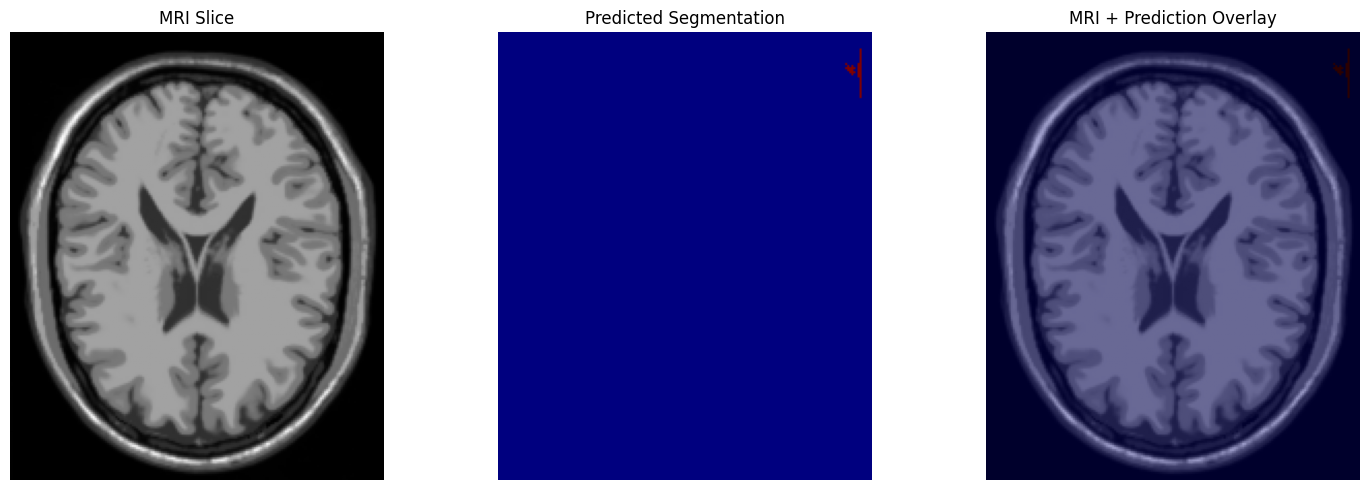


Saved:
final_segmentation32-16.npy

Inference Completed Successfully!


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device =", DEVICE)

# ============================================================
# EVALUATION MODE
# ============================================================

model.eval()

# ============================================================
# PATCH SETTINGS
# ============================================================

PATCH_SIZE = 32

STRIDE = 32

NUM_CLASSES = 4

# ============================================================
# INPUT MRI VOLUME
# ============================================================

input_volume = volume

DEPTH, HEIGHT, WIDTH = input_volume.shape

print("MRI Volume Shape =",
      input_volume.shape)

# ============================================================
# EMPTY PREDICTION VOLUME
# ============================================================

prediction_volume = np.zeros(
    (
        NUM_CLASSES,
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# COUNT VOLUME
# ============================================================

count_volume = np.zeros(
    (
        DEPTH,
        HEIGHT,
        WIDTH
    ),
    dtype=np.float32
)

# ============================================================
# SLIDING WINDOW INFERENCE
# ============================================================

print("\nStarting Inference...\n")

patch_count = 0

with torch.no_grad():

    for z in range(
        0,
        DEPTH - PATCH_SIZE + 1,
        STRIDE
    ):

        for y in range(
            0,
            HEIGHT - PATCH_SIZE + 1,
            STRIDE
        ):

            for x in range(
                0,
                WIDTH - PATCH_SIZE + 1,
                STRIDE
            ):

                # ------------------------------------------------
                # EXTRACT PATCH
                # ------------------------------------------------

                patch = input_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ]

                # ------------------------------------------------
                # SKIP EMPTY PATCHES
                # ------------------------------------------------

                if np.sum(patch) < 5:

                    continue

                # ------------------------------------------------
                # TO TENSOR
                # ------------------------------------------------

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                )

                # [D,H,W] -> [1,1,D,H,W]

                patch_tensor = patch_tensor.unsqueeze(0)
                patch_tensor = patch_tensor.unsqueeze(0)

                patch_tensor = patch_tensor.to(DEVICE)

                # ------------------------------------------------
                # MODEL PREDICTION
                # ------------------------------------------------

                outputs = model(
                    patch_tensor
                )

                # ------------------------------------------------
                # SOFTMAX
                # ------------------------------------------------

                probabilities = torch.softmax(
                    outputs,
                    dim=1
                )

                probabilities = probabilities.cpu().numpy()[0]

                # ------------------------------------------------
                # STORE PROBABILITIES
                # ------------------------------------------------

                prediction_volume[
                    :,
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += probabilities

                # ------------------------------------------------
                # UPDATE COUNTS
                # ------------------------------------------------

                count_volume[
                    z:z+PATCH_SIZE,
                    y:y+PATCH_SIZE,
                    x:x+PATCH_SIZE
                ] += 1

                patch_count += 1

                if patch_count % 20 == 0:

                    print(
                        f"Processed Patches = "
                        f"{patch_count}"
                    )

# ============================================================
# AVERAGE OVERLAPPING PATCHES
# ============================================================

print("\nAveraging Predictions...")

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

print("Prediction Volume Shape =",
      prediction_volume.shape)

# ============================================================
# FINAL SEGMENTATION
# ============================================================

final_segmentation = np.argmax(
    prediction_volume,
    axis=0
)

print("Final Segmentation Shape =",
      final_segmentation.shape)

print("Unique Labels =",
      np.unique(final_segmentation))

# ============================================================
# VISUALIZATION
# ============================================================

slice_index = DEPTH // 2

plt.figure(figsize=(15, 5))

# ------------------------------------------------------------
# MRI
# ------------------------------------------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    input_volume[slice_index],
    cmap="gray"
)

plt.title("MRI Slice")

plt.axis("off")

# ------------------------------------------------------------
# SEGMENTATION
# ------------------------------------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    final_segmentation[slice_index],
    cmap="jet"
)

plt.title("Predicted Segmentation")

plt.axis("off")

# ------------------------------------------------------------
# OVERLAY
# ------------------------------------------------------------

plt.subplot(1, 3, 3)

plt.imshow(
    input_volume[slice_index],
    cmap="gray"
)

plt.imshow(
    final_segmentation[slice_index],
    cmap="jet",
    alpha=0.35
)

plt.title("MRI + Prediction Overlay")

plt.axis("off")

plt.tight_layout()

plt.show()

# ============================================================
# SAVE SEGMENTATION
# ============================================================

np.save(
    "final_segmentation32-16.npy",
    final_segmentation
)

print("\nSaved:")
print("final_segmentation32-16.npy")

print("\nInference Completed Successfully!")

In [14]:
import numpy as np
import matplotlib.pyplot as plt

prediction_volume = prediction_volume / (
    count_volume[np.newaxis, ...] + 1e-8
)

final_segmentation23mayCleanedCode = np.argmax(
    prediction_volume,
    axis=0
)

print("Final Segmentation Shape =",
      final_segmentation23mayCleanedCode.shape)

print("Unique Labels =",
      np.unique(final_segmentation23mayCleanedCode))

slice_index = final_segmentation23mayCleanedCode.shape[0] // 2

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)

plt.imshow(
    input_volume[slice_index],
    cmap="gray"
)

plt.title("Original MRI")

plt.axis("off")

plt.subplot(1, 3, 2)

plt.imshow(
    final_segmentation23mayCleanedCode[slice_index],
    cmap="jet"
)

plt.title("Segmentation")

plt.axis("off")

plt.subplot(1, 3, 3)

plt.imshow(
    input_volume[slice_index],
    cmap="gray"
)

plt.imshow(
    final_segmentation23mayCleanedCode[slice_index],
    cmap="jet",
    alpha=0.35
)

plt.title("Overlay")

plt.axis("off")

plt.show()

np.save(
    "final_segmentation23mayCleanedCode.npy",
    final_segmentation23mayCleanedCode
)

print("\nSaved: final_segmentation23mayCleanedCode.npy")

NameError: name 'prediction_volume' is not defined

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

seg = np.load(
    "final_segmentation23mayCleanedCode.npy"
)

csf = seg == 1

gm = seg == 2

wm = seg == 3

STEP = 2

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(
    131,
    projection="3d"
)

ax1.voxels(
    csf[::STEP, ::STEP, ::STEP],
    alpha=0.5
)

ax1.set_title("3D CSF")

ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")

ax2 = fig.add_subplot(
    132,
    projection="3d"
)

ax2.voxels(
    gm[::STEP, ::STEP, ::STEP],
    alpha=0.5
)

ax2.set_title("3D Gray Matter")

ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

ax3 = fig.add_subplot(
    133,
    projection="3d"
)

ax3.voxels(
    wm[::STEP, ::STEP, ::STEP],
    alpha=0.5
)

ax3.set_title("3D White Matter")

ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")

plt.tight_layout()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'final_segmentation23mayCleanedCode.npy'